In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('../data/raw/kashwork_moderation.csv')
df.head()

,text,is_abusive,is_restricted,category
0,Durable coffee table for home and office,0,0,furniture
1,Nova laptop with 8GB RAM,0,0,laptop
2,football for fitness and training,0,0,sports
3,Durable fitness gloves for outdoor activities,0,0,sports
4,Prohibited narcotic product listed for purchas...,0,1,restricted_drug


In [3]:
df.shape

(1050, 4)

In [4]:
df.columns

Index(['text', 'is_abusive', 'is_restricted', 'category'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   text           1050 non-null   str  
 1   is_abusive     1050 non-null   int64
 2   is_restricted  1050 non-null   int64
 3   category       1050 non-null   str  
dtypes: int64(2), str(2)
memory usage: 32.9 KB


In [6]:
df.isnull().sum()

text             0
is_abusive       0
is_restricted    0
category         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(641)

## remove Duplicate Data

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(409, 4)

In [15]:
df["is_abusive"].value_counts()

is_abusive
0    389
1     20
Name: count, dtype: int64

In [16]:
df["is_restricted"].value_counts()

is_restricted
0    356
1     53
Name: count, dtype: int64

In [17]:
df["category"].value_counts()

category
mobile                  78
electronics             55
clothing                52
furniture               51
laptop                  38
books                   21
home                    21
sports                  20
abusive                 20
restricted_drug         10
restricted_medicine     10
restricted_weapon       10
restricted_explosive     8
restricted_alcohol       5
restricted_tobacco       5
restricted_other         5
Name: count, dtype: int64

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


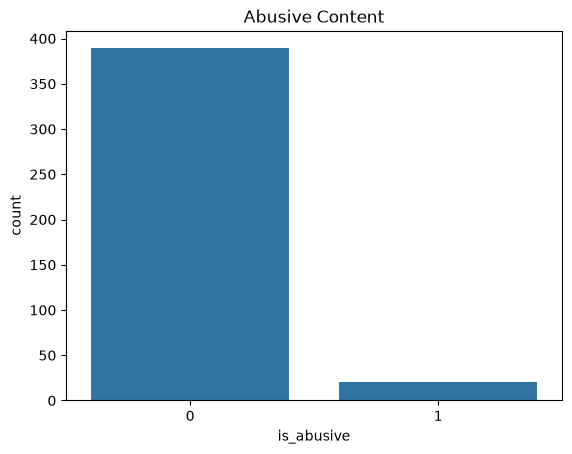

In [20]:
sns.countplot(data=df,x="is_abusive")
plt.title("Abusive Content")
plt.show()

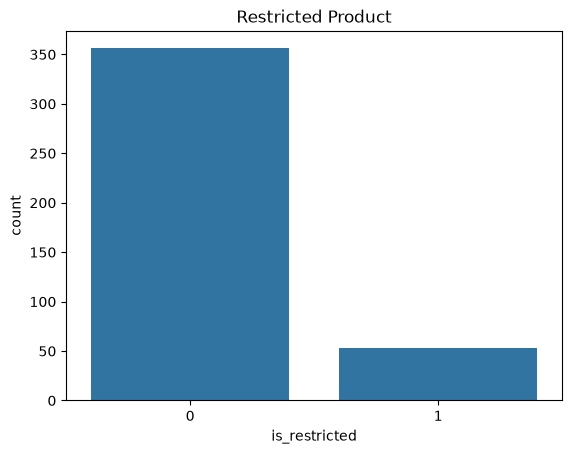

In [21]:
sns.countplot(data=df, x="is_restricted")
plt.title("Restricted Product")
plt.show()

## Cleaning

In [22]:
new_df=df.copy()
new_df.head()

,text,is_abusive,is_restricted,category
0,Durable coffee table for home and office,0,0,furniture
1,Nova laptop with 8GB RAM,0,0,laptop
2,football for fitness and training,0,0,sports
3,Durable fitness gloves for outdoor activities,0,0,sports
4,Prohibited narcotic product listed for purchas...,0,1,restricted_drug


In [24]:
new_df=new_df.dropna(subset=['text'])
new_df

,text,is_abusive,is_restricted,category
0,Durable coffee table for home and office,0,0,furniture
1,Nova laptop with 8GB RAM,0,0,laptop
2,football for fitness and training,0,0,sports
3,Durable fitness gloves for outdoor activities,0,0,sports
4,Prohibited narcotic product listed for purchas...,0,1,restricted_drug
...,...,...,...,...
1041,Bluetooth speaker with 8GB RAM,0,0,electronics
1043,Smart computer mouse featuring fast charging,0,0,electronics
1044,Stylish bedside table with a leather-style finish,0,0,furniture
1046,Bluetooth speaker with Bluetooth connectivity,0,0,electronics


In [26]:
new_df['text']=new_df['text'].astype(str)


In [28]:
new_df['text']=new_df['text'].str.strip()

In [34]:
new_df=new_df[df['text']!=' ']

In [ ]:
new_df.drop_duplicates(subset=['text'])

,text,is_abusive,is_restricted,category
0,Durable coffee table for home and office,0,0,furniture
1,Nova laptop with 8GB RAM,0,0,laptop
2,football for fitness and training,0,0,sports
3,Durable fitness gloves for outdoor activities,0,0,sports
4,Prohibited narcotic product listed for purchas...,0,1,restricted_drug
...,...,...,...,...
1041,Bluetooth speaker with 8GB RAM,0,0,electronics
1043,Smart computer mouse featuring fast charging,0,0,electronics
1044,Stylish bedside table with a leather-style finish,0,0,furniture
1046,Bluetooth speaker with Bluetooth connectivity,0,0,electronics


In [54]:
import sys
from pathlib import Path

ROOT_DIR=Path.cwd().parent

sys.path.append(str(ROOT_DIR))
from src.preprocessing import normalize_text

In [56]:
df["clean_text"] = df["text"].apply(normalize_text)

In [57]:
X=df['clean_text']
y_abusive = df["is_abusive"]
y_restricted = df["is_restricted"]

In [74]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y_abusive,
    test_size=0.2,
    random_state=42,
    stratify=y_abusive
)

In [75]:
len(X_test),len(y_test)

(82, 82)

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=1
)

In [77]:
X_train_tfidf=vectorizer.fit_transform(X_train)

In [83]:
X_test_tfidf=vectorizer.transform(X_test)

In [92]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3924 stored elements and shape (327, 686)>

In [93]:
from sklearn.linear_model import LogisticRegression

abusive_model=LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
abusive_model.fit(
    X_train_tfidf,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [94]:
predictions = abusive_model.predict(
    X_test_tfidf
)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [96]:
print(classification_report(
        y_test,
        predictions
    ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00         4

    accuracy                           1.00        82
   macro avg       1.00      1.00      1.00        82
weighted avg       1.00      1.00      1.00        82



In [98]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[78  0]
 [ 0  4]]


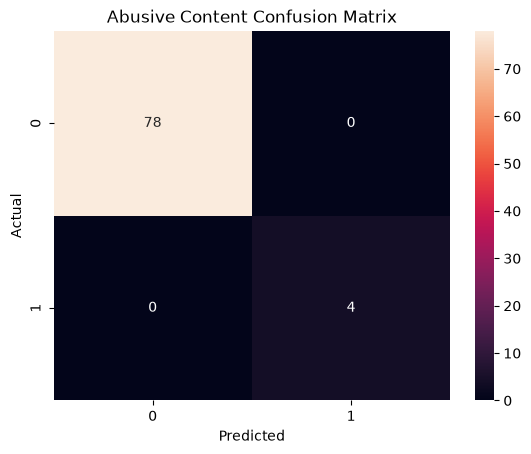

In [99]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Abusive Content Confusion Matrix")

plt.show()

In [100]:
X = df["clean_text"]

y_restricted = df["is_restricted"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_restricted,
    test_size=0.2,
    random_state=42,
    stratify=y_restricted
)

In [101]:
restricted_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1
)

In [103]:
X_train_r_tfidf = restricted_vectorizer.fit_transform(
    X_train_r
)

In [104]:
X_test_r_tfidf = restricted_vectorizer.transform(
    X_test_r
)

In [105]:
restricted_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

restricted_model.fit(
    X_train_r_tfidf,
    y_train_r
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [107]:
restricted_predictions = restricted_model.predict(
    X_test_r_tfidf
)

In [108]:
print(
    classification_report(
        y_test_r,
        restricted_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        11

    accuracy                           1.00        82
   macro avg       1.00      1.00      1.00        82
weighted avg       1.00      1.00      1.00        82



In [109]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [110]:
svm_predictions = svm_model.predict(
    X_test_tfidf
)

In [111]:
print(
    classification_report(
        y_test,
        svm_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00         4

    accuracy                           1.00        82
   macro avg       1.00      1.00      1.00        82
weighted avg       1.00      1.00      1.00        82



In [112]:
probabilities = abusive_model.predict_proba(
    X_test_tfidf
)

In [113]:
probabilities[0]

array([0.85759059, 0.14240941])

In [114]:
abusive_score = probabilities[:, 1]

In [115]:
def moderate(
    abusive_score,
    restricted_score
):

    if restricted_score >= 0.80:
        return "block"

    if abusive_score >= 0.80:
        return "block"

    if (
        restricted_score >= 0.40
        or abusive_score >= 0.40
    ):
        return "review"

    return "allow"

In [119]:
import joblib

In [122]:
joblib.dump(
    abusive_model,
    "../models/abusive_model.pkl"
)

['../models/abusive_model.pkl']

In [124]:
joblib.dump(
    vectorizer,
    "../models/abusive_vectorizer.pkl"
)

['../models/abusive_vectorizer.pkl']

In [125]:
joblib.dump(
    restricted_model,
    "../models/restricted_model.pkl"
)

joblib.dump(
    restricted_vectorizer,
    "../models/restricted_vectorizer.pkl"
)

['../models/restricted_vectorizer.pkl']